# **Day 95: Project 4 - Landslide Susceptibility Mapping**
*Module 13 - Remote Sensing ML and Publication Projects*

Landslide susceptibility mapping (LSM) is one of the most published RS/GIS + ML applications, and also one of the most criticised for weak methodology. A susceptibility map gives the **relative likelihood** that a landslide occurs at a location, given the local terrain and environmental "conditioning factors". It does not say *when* a slide will occur (that is hazard) or what is at risk (that is risk).

> **Working title**: *Machine-learning landslide susceptibility in a mountainous catchment: spatially and temporally independent validation of statistical and ML models.*

**What makes an LSM paper defensible?**
1. A clean **inventory** (initiation points or polygons), split in **time** for an independent check
2. Conditioning factors with a physical rationale, checked for **multicollinearity**
3. A documented strategy for **absence (non-landslide) sampling**
4. **Spatial** cross-validation, not random
5. **Success-rate** and **prediction-rate** curves, plus a **zonation** table
6. Interpretation (SHAP) consistent with geomorphology

> Landslide susceptibility maps show where slopes are most likely to fail, based on factors such as slope, rainfall, geology and roads. The key is honest validation with landslides that the model has not seen.
>
> *Example:* A steep slope cut by a new road on weak shale is far more susceptible than a gentle forested slope on granite.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from pathlib import Path
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import spearmanr
import xgboost as xgb, shap
import rs_utils as ru
ru.pub_style()
PROJ = Path("project4_landslide"); PROJ.mkdir(exist_ok=True)
SEED = 42

## **1. Study Area, Factors and Inventory**
The simulated 8 x 8 km mountainous area (relief of about 2 km, like the Himalayan foothills or the Western Ghats, where most Indian landslides occur) has a 20 m DEM, from which we derive the topographic factors. Note the hydrological steps:
- **Depression filling** (priority-flood, Barnes et al. 2014), so that water can flow to the edge
- **D8 flow accumulation** (the number of upslope cells)
- **Topographic Wetness Index**: TWI = ln(a / tan beta), with a the specific catchment area
- **Streams** = cells with large flow accumulation, then distance to streams

The inventory holds landslide **initiation points** from two storm events. Period 1 is used for modelling. Period 2, a later storm, is kept aside as a **temporally independent** test, as if mapped from new imagery after the model was built.

{'elevation_m': '150.0 to 2177.7', 'slope_deg': '0.0 to 66.6', 'aspect_deg': '0.0 to 360.0', 'curvature': '-1.4 to 2.1', 'TWI': '2.3 to 18.3', 'dist_stream_m': '0.0 to 1261.3', 'dist_road_m': '0.0 to 5052.8', 'rainfall_mm': '1101.9 to 1628.9', 'lithology': '0.0 to 3.0', 'landcover': '0.0 to 5.0'}
{'period 1 (modelling)': 248, 'period 2 (independent test)': 161}


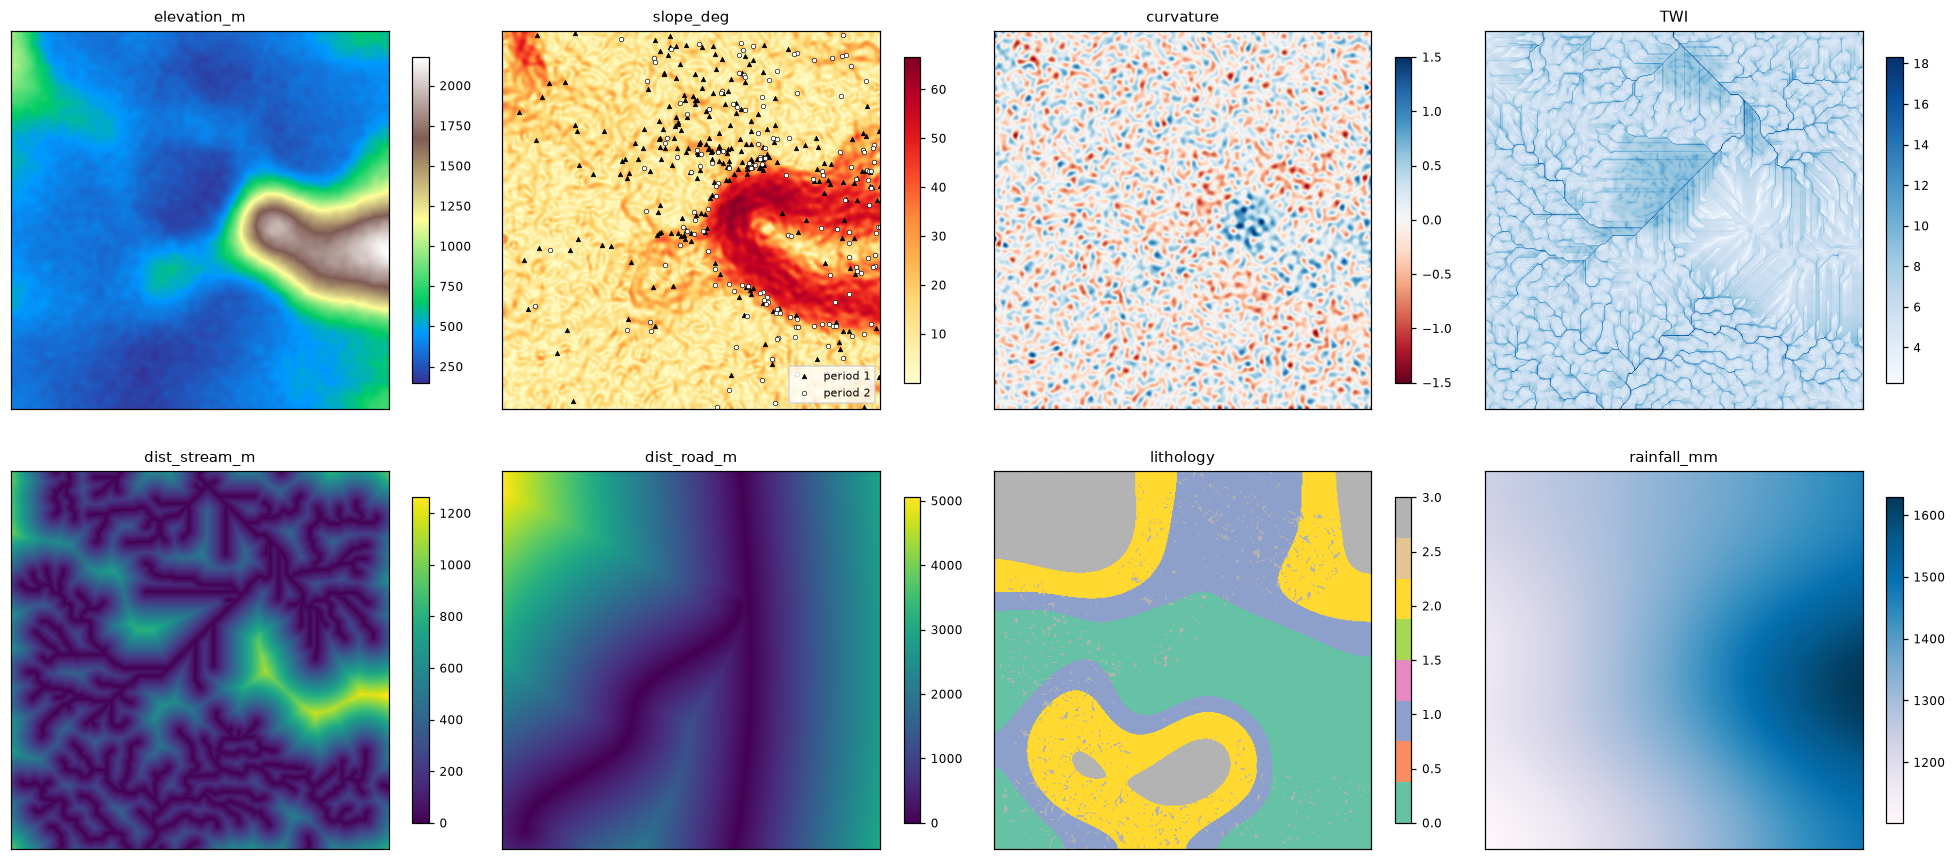

In [2]:
area = ru.make_landslide_area(seed=3)
F, inv, T = area["factors"], area["inventory"], area["transform"]
H, W = F["slope_deg"].shape; ext = ru.map_extent(T, (H, W))
print({k: f"{v.min():.1f} to {v.max():.1f}" for k, v in F.items()})
print(inv.period.value_counts().rename({1: "period 1 (modelling)", 2: "period 2 (independent test)"}).to_dict())

fig, axes = plt.subplots(2, 4, figsize=(18, 8.5))
for ax, (k, cm) in zip(axes.ravel(), [("elevation_m", "terrain"), ("slope_deg", "YlOrRd"), ("curvature", "RdBu"), ("TWI", "Blues"),
                                      ("dist_stream_m", "viridis"), ("dist_road_m", "viridis"), ("lithology", "Set2"), ("rainfall_mm", "PuBu")]):
    v = F[k]; kw = dict(vmin=-1.5, vmax=1.5) if k == "curvature" else {}
    im = ax.imshow(v, cmap=cm, extent=ext, **kw); fig.colorbar(im, ax=ax, shrink=0.7); ax.set_title(k); ax.set_xticks([]); ax.set_yticks([])
for p, mk in [(1, "k^"), (2, "wo")]:
    s = inv[inv.period == p]; axes[0, 1].plot(s.x, s.y, mk, ms=3, mec="k", mew=0.4, label=f"period {p}")
axes[0, 1].legend(fontsize=7, loc="lower right")
plt.tight_layout(); fig.savefig(PROJ / "fig1_factors.png", dpi=300, bbox_inches="tight"); plt.show()

## **2. Sampling Absences and Building the Table**
Landslides are presence-only data. We draw **absence points** at random from cells farther than 100 m from any mapped landslide (period 1), at a ratio of 1 : 3. The choice of absences shapes the model as much as the choice of algorithm (Part 2 tests it), so state it explicitly in the paper.

In [3]:
rng = np.random.default_rng(SEED)
from scipy.ndimage import distance_transform_edt
p1 = inv[inv.period == 1]; p2 = inv[inv.period == 2]
ls_mask = np.zeros((H, W), bool); ls_mask[p1.row, p1.col] = True
far = distance_transform_edt(~ls_mask) * 20 > 100
cand = np.flatnonzero(far.ravel() & (F["landcover"].ravel() != 0))                    # exclude water bodies
neg = rng.choice(cand, 3 * len(p1), replace=False)
rows = np.concatenate([p1.row.values, neg // W]); cols = np.concatenate([p1.col.values, neg % W])
y = np.concatenate([np.ones(len(p1)), np.zeros(len(neg))]).astype(int)
num_cols = ["elevation_m", "slope_deg", "curvature", "TWI", "dist_stream_m", "dist_road_m", "rainfall_mm"]
df = pd.DataFrame({k: F[k][rows, cols] for k in num_cols})
df["northness"] = np.cos(np.radians(F["aspect_deg"][rows, cols])); df["eastness"] = np.sin(np.radians(F["aspect_deg"][rows, cols]))
df["lithology"] = F["lithology"][rows, cols].astype(int)                         # integer codes (names in area["lithology_names"])
df["landcover"] = F["landcover"][rows, cols].astype(int)                         # integer codes (names in ru.LC_CLASSES)
xs, ys_ = ru.pixel_centres(T, rows, cols); df["block"] = ru.spatial_blocks(xs, ys_, 1000)
df["landslide"] = y
print(df.shape, f"| prevalence in the table {y.mean():.2f}")
df.groupby("landslide")[num_cols].median().round(2)

(992, 13) | prevalence in the table 0.25


,elevation_m,slope_deg,curvature,TWI,dist_stream_m,dist_road_m,rainfall_mm
landslide,,,,,,,
0,381.579987,13.56,0.02,5.99,184.389999,1131.369995,1333.689941
1,338.579987,21.76,-0.07,7.02,150.899994,831.950012,1380.650024


## **3. Multicollinearity: VIF**
Highly collinear factors make logistic-regression coefficients unstable and spread importance arbitrarily between features. A common rule: drop or merge factors with **VIF > 5-10**. Elevation and rainfall, or TWI and slope, are typical suspects.

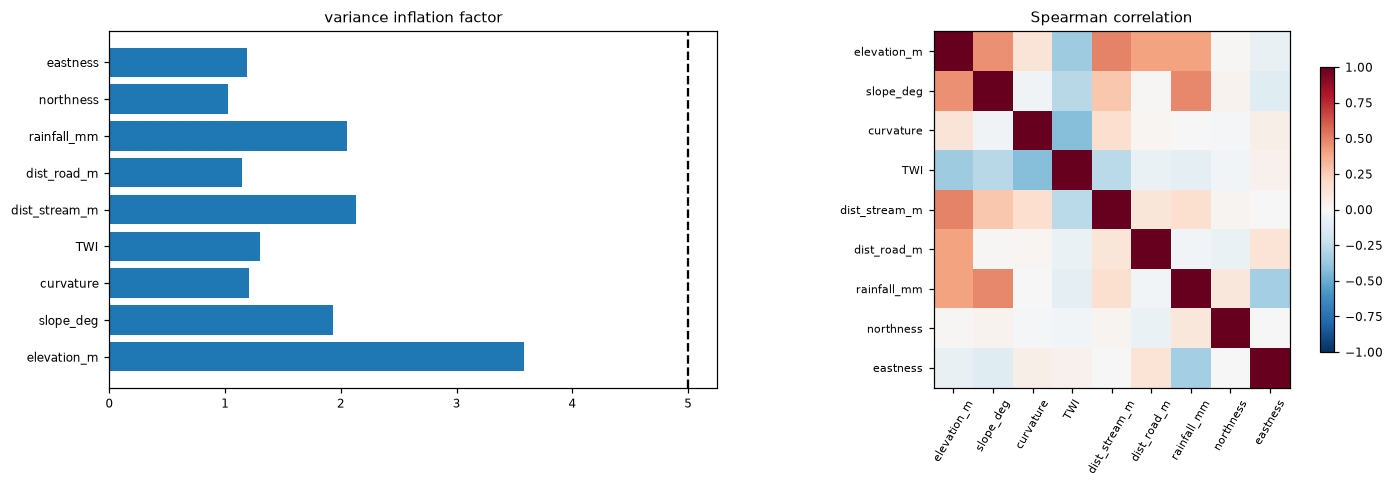

,factor,VIF
0,elevation_m,3.58
1,slope_deg,1.93
2,curvature,1.21
3,TWI,1.30
4,dist_stream_m,2.13
5,dist_road_m,1.15
6,rainfall_mm,2.06
7,northness,1.03
8,eastness,1.19


In [4]:
num_all = num_cols + ["northness", "eastness"]
Z = StandardScaler().fit_transform(df[num_all])
vif = pd.DataFrame({"factor": num_all, "VIF": [variance_inflation_factor(np.c_[np.ones(len(Z)), Z], i + 1) for i in range(len(num_all))]})
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(vif.factor, vif.VIF, color=np.where(vif.VIF > 5, "tab:red", "tab:blue")); axes[0].axvline(5, ls="--", c="k"); axes[0].set_title("variance inflation factor")
im = axes[1].imshow(df[num_all].corr(method="spearman"), cmap="RdBu_r", vmin=-1, vmax=1); axes[1].set_xticks(range(len(num_all)), num_all, rotation=60, fontsize=7)
axes[1].set_yticks(range(len(num_all)), num_all, fontsize=7); fig.colorbar(im, ax=axes[1], shrink=0.8); axes[1].set_title("Spearman correlation")
plt.tight_layout(); plt.show()
vif.round(2)

## **4. The Frequency Ratio Method (Bivariate Statistics)**
For each class of each factor: FR = (% of landslides in the class) / (% of area in the class). FR > 1 means the class is more landslide-prone than average. The **landslide susceptibility index** is LSI = sum of the FRs of the classes a cell falls in. FR is transparent and still widely used as a baseline. Continuous factors are classified by deciles.

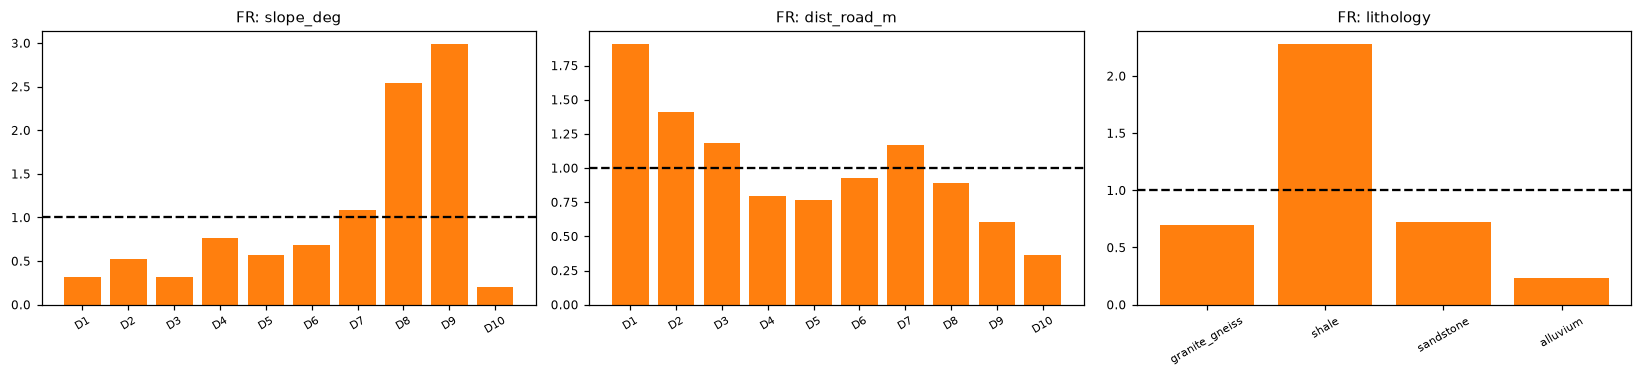

In [5]:
def fr_tables(factors, inv_rows, inv_cols, n_bins=10, categorical=("lithology", "landcover")):
    tables, class_maps = {}, {}
    for k, v in factors.items():
        if k == "aspect_deg": continue
        cls = v.astype(int) if k in categorical else np.digitize(v, np.unique(np.quantile(v, np.linspace(0, 1, n_bins + 1)[1:-1])))
        n_cls = cls.max() + 1
        area_share = np.bincount(cls.ravel(), minlength=n_cls) / cls.size
        ls_share = np.bincount(cls[inv_rows, inv_cols], minlength=n_cls) / len(inv_rows)
        tables[k] = ls_share / np.maximum(area_share, 1e-9); class_maps[k] = cls
    return tables, class_maps

fr, cls_maps = fr_tables(F, p1.row.values, p1.col.values)
lsi_fr = sum(fr[k][cls_maps[k]] for k in fr)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, k in zip(axes, ["slope_deg", "dist_road_m", "lithology"]):
    ax.bar(range(len(fr[k])), fr[k], color="tab:orange"); ax.axhline(1, ls="--", c="k"); ax.set_title(f"FR: {k}")
    ax.set_xticks(range(len(fr[k])), area["lithology_names"] if k == "lithology" else [f"D{i + 1}" for i in range(len(fr[k]))], rotation=30, fontsize=7)
plt.tight_layout(); plt.show()

## **5. ML Models under Spatial Cross-Validation**
Models: **logistic regression** and **random forest** (with one-hot categorical factors) and **XGBoost** (which splits directly on the integer codes; trees can isolate any code with a few splits). Folds are 1 km spatial blocks. We report the ROC AUC for each fold, and the same models under **random** CV for contrast. Landslides cluster on the same slopes, so random CV inflates AUC.

In [6]:
cat_cols = ["lithology", "landcover"]
feats = num_all + cat_cols
pre = ColumnTransformer([("num", StandardScaler(), num_all), ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])
models = {"Logistic regression": lambda: make_pipeline(pre, LogisticRegression(max_iter=2000, C=1.0)),
          "Random forest": lambda: make_pipeline(ColumnTransformer([("num", "passthrough", num_all), ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)]),
                                                 RandomForestClassifier(500, min_samples_leaf=3, n_jobs=-1, random_state=SEED)),
          "XGBoost": lambda: xgb.XGBClassifier(n_estimators=400, learning_rate=0.03, max_depth=4, subsample=0.8, colsample_bytree=0.8,
                                               enable_categorical=False, tree_method="hist", random_state=SEED, n_jobs=-1)}
X = df[feats]
def cv_auc(make, splitter, groups=None):
    out = []
    for tr, te in splitter.split(X, y, groups):
        m = make().fit(X.iloc[tr], y[tr]); out.append(roc_auc_score(y[te], m.predict_proba(X.iloc[te])[:, 1]))
    return np.array(out)
res = {}
for name, mk in models.items():
    sp = cv_auc(mk, GroupKFold(5), df["block"]); rd = cv_auc(mk, StratifiedKFold(5, shuffle=True, random_state=SEED))
    res[name] = {"spatial CV AUC": sp.mean(), "s.d.": sp.std(), "random CV AUC": rd.mean(), "optimism": rd.mean() - sp.mean()}
fr_auc = roc_auc_score(y, lsi_fr[rows, cols])
res["Frequency ratio (in-sample)"] = {"spatial CV AUC": np.nan, "s.d.": np.nan, "random CV AUC": np.nan, "optimism": np.nan}
table1 = pd.DataFrame(res).T; table1.loc["Frequency ratio (in-sample)", "random CV AUC"] = fr_auc
table1.round(3)

,spatial CV AUC,s.d.,random CV AUC,optimism
Logistic regression,0.795,0.082,0.817,0.021
Random forest,0.820,0.075,0.857,0.037
XGBoost,0.806,0.061,0.853,0.047
Frequency ratio (in-sample),NaN,NaN,0.850,NaN


The FR row is an in-sample AUC (its class ratios were computed from the same landslides), so it is optimistic by construction. Section 6 compares all models fairly on the **independent period-2 inventory**.

## **6. Susceptibility Maps, Success and Prediction Rates**
Fit each model on all period-1 data and predict every cell. Then:
- **Success-rate curve**: cumulative % of *training* landslides against the % of the area ranked from most to least susceptible (goodness of fit)
- **Prediction-rate curve**: the same with the *independent* period-2 landslides (predictive power). The area under it is the key number.

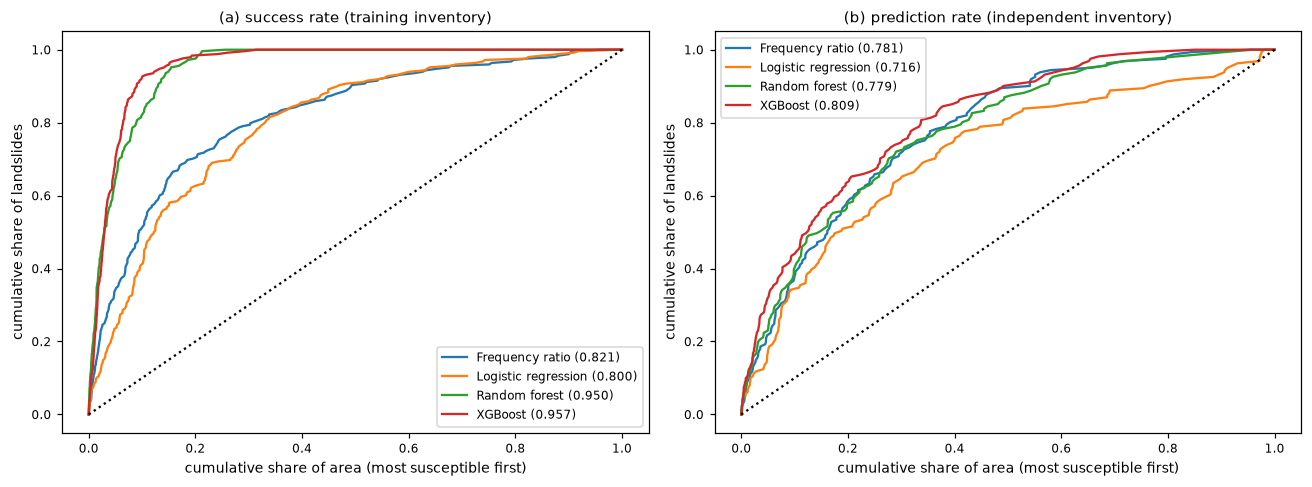

,success-rate AUC (period 1),prediction-rate AUC (period 2),Spearman with TRUE probability (simulation only)
model,,,
Frequency ratio,0.821,0.781,0.769
Logistic regression,0.800,0.716,0.654
Random forest,0.950,0.779,0.760
XGBoost,0.957,0.809,0.777


In [7]:
grid_df = pd.DataFrame({k: F[k].ravel() for k in num_cols})
grid_df["northness"] = np.cos(np.radians(F["aspect_deg"].ravel())); grid_df["eastness"] = np.sin(np.radians(F["aspect_deg"].ravel()))
grid_df["lithology"] = F["lithology"].ravel().astype(int); grid_df["landcover"] = F["landcover"].ravel().astype(int)
maps = {"Frequency ratio": lsi_fr}
fitted = {}
for name, mk in models.items():
    fitted[name] = mk().fit(X, y); maps[name] = fitted[name].predict_proba(grid_df[feats])[:, 1].reshape(H, W)

def rate_curve(susc, inv_df):
    order = np.argsort(-susc.ravel(), kind="stable"); rank = np.empty_like(order); rank[order] = np.arange(order.size)
    frac_area = np.sort(rank[inv_df.row.values * W + inv_df.col.values]) / order.size
    yv = np.arange(1, len(frac_area) + 1) / len(frac_area)
    return frac_area, yv, np.trapezoid(np.r_[0, yv, 1], np.r_[0, frac_area, 1])

valid = F["landcover"] != 0
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5)); rows_tab = []
for name, m in maps.items():
    s = np.where(valid, m, -np.inf)
    fa1, y1, auc1 = rate_curve(s, p1); fa2, y2, auc2 = rate_curve(s, p2)
    axes[0].plot(np.r_[0, fa1, 1], np.r_[0, y1, 1], label=f"{name} ({auc1:.3f})"); axes[1].plot(np.r_[0, fa2, 1], np.r_[0, y2, 1], label=f"{name} ({auc2:.3f})")
    rows_tab.append({"model": name, "success-rate AUC (period 1)": auc1, "prediction-rate AUC (period 2)": auc2,
                     "Spearman with TRUE probability (simulation only)": spearmanr(m[valid], area["true_prob"][valid]).statistic})
for ax, t in zip(axes, ["(a) success rate (training inventory)", "(b) prediction rate (independent inventory)"]):
    ax.plot([0, 1], [0, 1], "k:"); ax.set_xlabel("cumulative share of area (most susceptible first)"); ax.set_ylabel("cumulative share of landslides"); ax.set_title(t); ax.legend(fontsize=8)
plt.tight_layout(); fig.savefig(PROJ / "fig2_rate_curves.png", dpi=300, bbox_inches="tight"); plt.show()
table2 = pd.DataFrame(rows_tab).set_index("model"); table2.round(3).to_csv(PROJ / "table2_rates.csv"); table2.round(3)

## **7. Zonation (Table 3, Fig. 3)**
Maps are communicated as **classes**: very low to very high. Classify the best model's susceptibility by area percentiles (here 50 / 20 / 15 / 10 / 5% of the area) and check that landslide **density** rises steeply across classes. Report the share of area and the share of landslides per class. A good map puts many landslides into a small "very high" area.

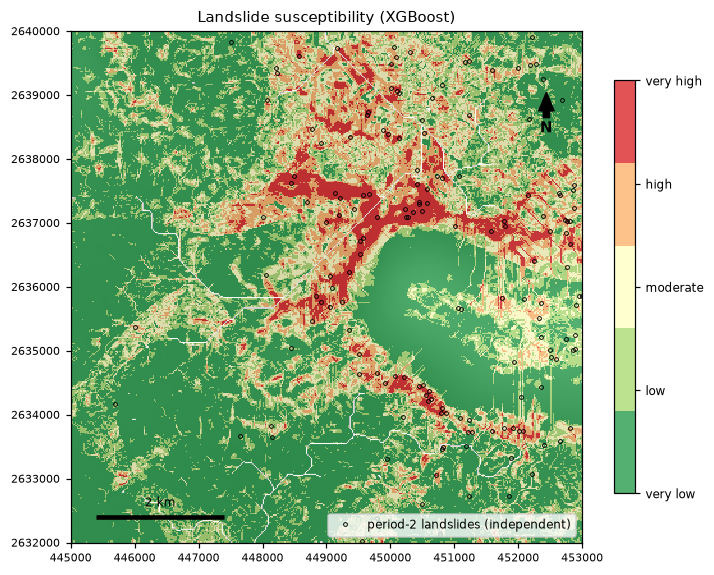

,% area,% landslides period 1,% landslides period 2,density ratio (period 2)
zone,,,,
very low,50.0,0.00,9.94,0.20
low,20.0,0.40,16.15,0.81
moderate,15.0,4.03,18.63,1.24
high,10.0,27.02,23.60,2.36
very high,5.0,68.55,31.68,6.33


In [8]:
best = table2["prediction-rate AUC (period 2)"].drop("Frequency ratio").idxmax()
s = np.where(valid, maps[best], np.nan)
breaks = np.nanpercentile(s, [50, 70, 85, 95]); zone = np.digitize(np.nan_to_num(s, nan=-1), breaks); zone[~valid] = -1
names = ["very low", "low", "moderate", "high", "very high"]
tab3 = []
for k, nm in enumerate(names):
    a = np.mean(zone[valid] == k); l1 = np.mean(zone[p1.row, p1.col] == k); l2 = np.mean(zone[p2.row, p2.col] == k)
    tab3.append({"zone": nm, "% area": 100 * a, "% landslides period 1": 100 * l1, "% landslides period 2": 100 * l2, "density ratio (period 2)": l2 / a})
table3 = pd.DataFrame(tab3).set_index("zone"); table3.round(2).to_csv(PROJ / "table3_zonation.csv")
from matplotlib.colors import ListedColormap
fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.imshow(np.where(valid, F["elevation_m"], np.nan), cmap="gray", extent=ext, alpha=0.6)
im = ax.imshow(np.ma.masked_less(zone, 0), cmap=ListedColormap(["#1a9641", "#a6d96a", "#ffffbf", "#fdae61", "#d7191c"]), extent=ext, alpha=0.75, interpolation="nearest")
ax.plot(p2.x, p2.y, "ko", ms=2.5, mfc="none", mew=0.6, label="period-2 landslides (independent)")
cb = fig.colorbar(im, ax=ax, shrink=0.75, ticks=range(5)); cb.ax.set_yticklabels(names)
ru.add_scalebar(ax, 2000, ext); ru.add_north_arrow(ax); ax.legend(loc="lower right", fontsize=8); ax.set_title(f"Landslide susceptibility ({best})")
ax.ticklabel_format(style="plain"); ax.tick_params(labelsize=7)
fig.savefig(PROJ / "fig3_susceptibility_map.png", dpi=300, bbox_inches="tight"); plt.show()
table3.round(2)

## **8. Interpretation with SHAP**
Check the model against geomorphology. Susceptibility should rise with slope up to a maximum and fall on the steepest (rock) slopes, increase near road cuts, and be higher on weak lithologies. A model that contradicts process knowledge is a red flag, even when its AUC is high.

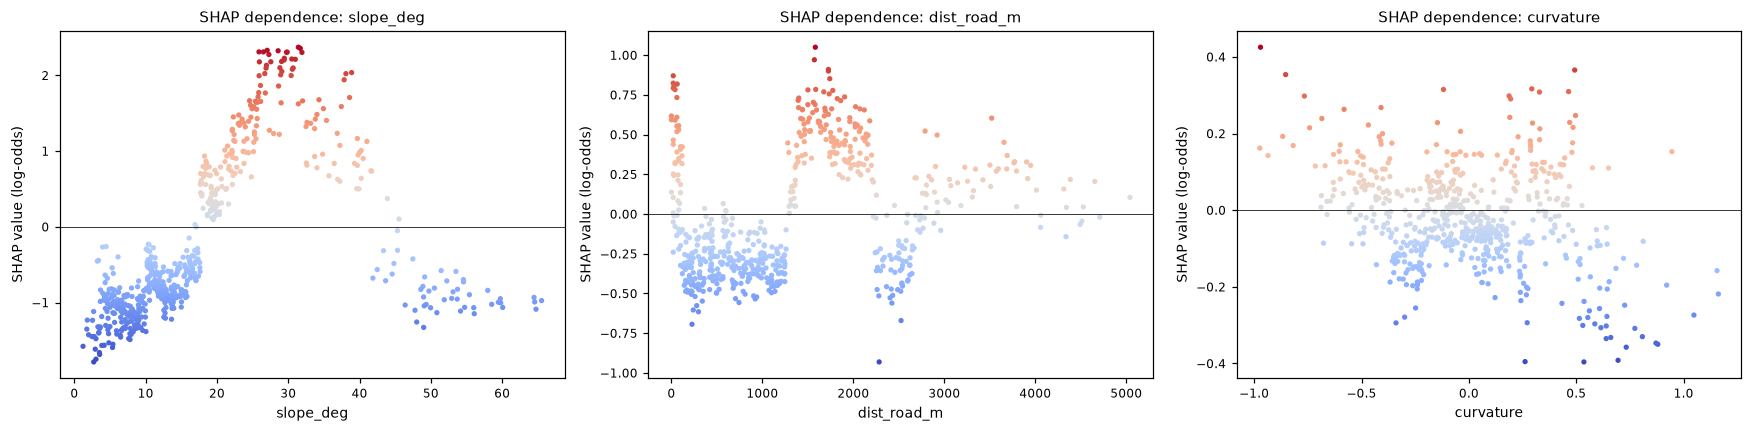

slope_deg        0.963
lithology        0.546
TWI              0.516
rainfall_mm      0.492
dist_road_m      0.338
elevation_m      0.330
landcover        0.284
eastness         0.189
dist_stream_m    0.178
northness        0.126
curvature        0.100
dtype: float32

In [9]:
xg = fitted["XGBoost"]
expl = shap.TreeExplainer(xg)
sv = expl(X.sample(600, random_state=SEED))
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, f in zip(axes, ["slope_deg", "dist_road_m", "curvature"]):
    j = feats.index(f); xv = sv.data[:, j].astype(float)
    ax.scatter(xv, sv.values[:, j], s=6, c=sv.values[:, j], cmap="coolwarm"); ax.axhline(0, c="k", lw=0.5)
    ax.set_xlabel(f); ax.set_ylabel("SHAP value (log-odds)"); ax.set_title(f"SHAP dependence: {f}")
plt.tight_layout(); fig.savefig(PROJ / "fig4_shap.png", dpi=300, bbox_inches="tight"); plt.show()
imp = pd.Series(np.abs(sv.values).mean(0), index=feats).sort_values(ascending=False)
imp.round(3)

# **Part 2: Going Deeper**

## **9. Absence Sampling Changes the Map**
Three common strategies:
- **A**: random cells farther than 100 m from landslides (used above)
- **B**: random cells only on slopes < 10 deg ("obviously stable" areas). Popular, but it makes the problem artificially easy: the model learns "steep vs flat"
- **C**: random cells farther than 1 km from landslides, which removes all similar terrain

Compare their spatial-CV AUC with the independent prediction rate and with the true probability, which reveal the truth.

In [10]:
def absences(strategy, n):
    if strategy == "A": c = cand
    elif strategy == "B": c = np.flatnonzero(far.ravel() & (F["slope_deg"].ravel() < 10) & (F["landcover"].ravel() != 0))
    else: c = np.flatnonzero((distance_transform_edt(~ls_mask) * 20 > 1000).ravel() & (F["landcover"].ravel() != 0))
    return rng.choice(c, min(n, len(c)), replace=False)
abs_rows = []
for strat in ["A", "B", "C"]:
    ng = absences(strat, 3 * len(p1)); rr = np.concatenate([p1.row.values, ng // W]); cc = np.concatenate([p1.col.values, ng % W])
    yy = np.r_[np.ones(len(p1)), np.zeros(len(ng))].astype(int)
    d = grid_df.iloc[rr * W + cc].reset_index(drop=True); bx, by = ru.pixel_centres(T, rr, cc); g = ru.spatial_blocks(bx, by, 1000)
    aucs = [roc_auc_score(yy[te], models["XGBoost"]().fit(d[feats].iloc[tr], yy[tr]).predict_proba(d[feats].iloc[te])[:, 1]) for tr, te in GroupKFold(5).split(d, yy, g)]
    m = models["XGBoost"]().fit(d[feats], yy); smap = m.predict_proba(grid_df[feats])[:, 1].reshape(H, W)
    abs_rows.append({"absence strategy": strat, "spatial CV AUC": np.mean(aucs), "prediction-rate AUC (period 2)": rate_curve(np.where(valid, smap, -np.inf), p2)[2],
                     "Spearman with TRUE probability": spearmanr(smap[valid], area["true_prob"][valid]).statistic, "n absences": len(ng)})
pd.DataFrame(abs_rows).set_index("absence strategy").round(3)

,spatial CV AUC,prediction-rate AUC (period 2),Spearman with TRUE probability,n absences
absence strategy,,,,
A,0.815,0.811,0.774,744
B,0.950,0.743,0.485,744
C,0.691,0.732,0.642,744


Strategy B makes the absences "easy" (flat land versus steep slopes). Its CV AUC looks excellent, but its map is clearly worse on the independent inventory and far from the true susceptibility. Strategy C removes every absence from terrain similar to the landslides, which distorts the sample so much that both the CV score and the map get worse. Only strategy A, with absences drawn from the whole landscape, gives a map that agrees well with the truth. Only the independent inventory and, in simulation, the true probability show this. This is one of the most important lessons for reviewing LSM papers.

## **Practice Problems**
1. Remove `dist_road_m` from the factors. How do the prediction-rate AUC and the map change? Discuss why road cuts are a legitimate but **anthropogenic** factor.
2. Replace the 1:3 ratio with 1:1 and 1:10. Does AUC change? Does the probability scale change?
3. Classify the best map with **equal-interval** breaks instead of area percentiles. Compare the zonation tables.
4. *(Advanced)* Compute the spatial-CV AUC with block sizes of 250 m, 1 km and 2 km for XGBoost. Relate the result to the clustering of the landslides.

In [11]:
# Solution 1
feats_nr = [f for f in feats if f != "dist_road_m"]
m_nr = xgb.XGBClassifier(n_estimators=400, learning_rate=0.03, max_depth=4, subsample=0.8, colsample_bytree=0.8, enable_categorical=False,
                         tree_method="hist", random_state=SEED, n_jobs=-1).fit(X[feats_nr], y)
s_nr = m_nr.predict_proba(grid_df[feats_nr])[:, 1].reshape(H, W)
print(f"prediction-rate AUC without roads {rate_curve(np.where(valid, s_nr, -np.inf), p2)[2]:.3f} vs with roads {table2.loc['XGBoost', 'prediction-rate AUC (period 2)']:.3f}")

prediction-rate AUC without roads 0.812 vs with roads 0.809


In [12]:
# Solution 2
for ratio in [1, 3, 10]:
    ng = rng.choice(cand, ratio * len(p1), replace=False); rr = np.r_[p1.row.values, ng // W]; cc = np.r_[p1.col.values, ng % W]
    yy = np.r_[np.ones(len(p1)), np.zeros(len(ng))].astype(int); d = grid_df.iloc[rr * W + cc]
    m = models["XGBoost"]().fit(d[feats], yy); smap = m.predict_proba(grid_df[feats])[:, 1].reshape(H, W)
    print(f"1:{ratio:<2} prediction-rate AUC {rate_curve(np.where(valid, smap, -np.inf), p2)[2]:.3f} | mean predicted probability {smap[valid].mean():.3f}")
print("Ranking (AUC) is stable; the probability scale follows the sampling ratio, so treat the output as a relative index.")

1:1  prediction-rate AUC 0.826 | mean predicted probability 0.340


1:3  prediction-rate AUC 0.795 | mean predicted probability 0.170


1:10 prediction-rate AUC 0.816 | mean predicted probability 0.078
Ranking (AUC) is stable; the probability scale follows the sampling ratio, so treat the output as a relative index.


In [13]:
# Solution 3
eq = np.digitize(np.nan_to_num(s, nan=-1), np.linspace(np.nanmin(s), np.nanmax(s), 6)[1:-1]); eq[~valid] = -1
print(pd.DataFrame({"% area": [100 * np.mean(eq[valid] == k) for k in range(5)], "% landslides period 2": [100 * np.mean(eq[p2.row, p2.col] == k) for k in range(5)]}, index=names).round(2))

           % area  % landslides period 2
very low    73.23                  29.81
low         12.68                  16.15
moderate     6.42                  15.53
high         4.34                  14.29
very high    3.32                  24.22


In [14]:
# Solution 4
for bs in [250, 1000, 2000]:
    g = ru.spatial_blocks(*ru.pixel_centres(T, rows, cols), bs)
    print(f"block {bs:>4} m: spatial CV AUC {cv_auc(models['XGBoost'], GroupKFold(5), g).mean():.3f}")

block  250 m: spatial CV AUC 0.842


block 1000 m: spatial CV AUC 0.806


block 2000 m: spatial CV AUC 0.776


## **Key References**
- Reichenbach, P., Rossi, M., Malamud, B. D., Mihir, M., & Guzzetti, F. (2018). A review of statistically-based landslide susceptibility models. *Earth-Science Reviews*, 180, 60-91.
- Guzzetti, F., Reichenbach, P., Ardizzone, F., Cardinali, M., & Galli, M. (2006). Estimating the quality of landslide susceptibility models. *Geomorphology*, 81(1-2), 166-184.
- Chung, C.-J. F., & Fabbri, A. G. (2003). Validation of spatial prediction models for landslide hazard mapping. *Natural Hazards*, 30(3), 451-472.
- Brenning, A. (2005). Spatial prediction models for landslide hazards: review, comparison and evaluation. *Natural Hazards and Earth System Sciences*, 5(6), 853-862.
- Steger, S., Brenning, A., Bell, R., & Glade, T. (2016). The propagation of inventory-based positional errors into statistical landslide susceptibility models. *Natural Hazards and Earth System Sciences*, 16(12), 2729-2745.
- Barnes, R., Lehman, C., & Mulla, D. (2014). Priority-flood: An optimal depression-filling and watershed-labeling algorithm for digital elevation models. *Computers & Geosciences*, 62, 117-127.
- Beven, K. J., & Kirkby, M. J. (1979). A physically based, variable contributing area model of basin hydrology. *Hydrological Sciences Bulletin*, 24(1), 43-69.